### 3. 理论和实验证明，一个两层的ReLU网络可以模拟任何有界闭集画数

#### 1. 分段线性函数逼近定理
- 利用经典的逼近理论，可以证明：对于定义在有界闭集上的任意连续函数，通过足够精细的分割域，可以构造出分段线性函数，使得分段线性函数在任意给定精度内逼近目标函数。  
- 这个结果类似于经典的Weierstrass逼近定理，不过这里使用的是分段线性函数，而不是多项式。事实上，由于有界闭集（紧集）上连续函数具有一致连续性，我们可以对域进行足够细的划分，然后在每个小区间内用线性函数来近似原函数。

#### 2. 两层ReLU网络表达分段线性函数
- ReLU函数本身定义为 $\text{ReLU}(x) = \max\{0,x\}$，是一个分段线性函数（在负半轴为常数0，在正半轴为线性函数）。  
- 可以证明，具有足够神经元的两层ReLU网络（也称为单隐层网络）可以精确地表达任何分段线性函数。  
  - 第一层通过线性组合和ReLU激活构造出多个“hinge”函数（即分段点附近的激活变化）。  
  - 第二层对这些“hinge”函数进行加权求和，从而组合成任意复杂的分段线性结构。

#### 证明

- **逼近连续函数**：  
  利用步骤1，我们知道任何定义在有界闭集上的连续函数 \(f\) 都可以通过分段线性函数 \(g\) 以任意小的误差进行均匀逼近，即  
  $$\sup_{x \in K} |f(x) - g(x)| < \epsilon.$$
  
- **实现分段线性函数**：  
  根据步骤2，存在一个两层ReLU网络 \(N\) 能够精确表达这个分段线性函数 \(g\)，即 \(N(x) = g(x)\) 对所有 \(x\) 成立。

- **得出结论**：  
  由此，对于任意给定的 \(\epsilon > 0\)，可以构造一个两层ReLU网络使得  
  $$  \sup_{x \in K} |f(x) - N(x)| < \epsilon.$$
  这就证明了两层ReLU网络在有界闭集上是具有普适逼近能力的（即**通用逼近定理**）。

#### 1. numpy

Epoch 0, Loss: 14.018204130821363
Epoch 100, Loss: 0.3574059678226479
Epoch 200, Loss: 0.3015147337549683
Epoch 300, Loss: 0.25731793813168286
Epoch 400, Loss: 0.22437111524543066
Epoch 500, Loss: 0.20204964729015654
Epoch 600, Loss: 0.18844699273077622
Epoch 700, Loss: 0.18075967399097506
Epoch 800, Loss: 0.1765587395432193
Epoch 900, Loss: 0.17412834162477392
Epoch 1000, Loss: 0.1725808641538225
Epoch 1100, Loss: 0.17138577920023426
Epoch 1200, Loss: 0.1704432166845021
Epoch 1300, Loss: 0.16960053963914415
Epoch 1400, Loss: 0.1687915856015114
Epoch 1500, Loss: 0.1680564304557289
Epoch 1600, Loss: 0.16733761823380217
Epoch 1700, Loss: 0.16664204891051732
Epoch 1800, Loss: 0.16598684263999025
Epoch 1900, Loss: 0.16536322044909935
Epoch 2000, Loss: 0.16476605869689412
Epoch 2100, Loss: 0.1641886894699201
Epoch 2200, Loss: 0.163614164208692
Epoch 2300, Loss: 0.16304373932826807
Epoch 2400, Loss: 0.16252189299229236
Epoch 2500, Loss: 0.1620204497885338
Epoch 2600, Loss: 0.1615376403318820

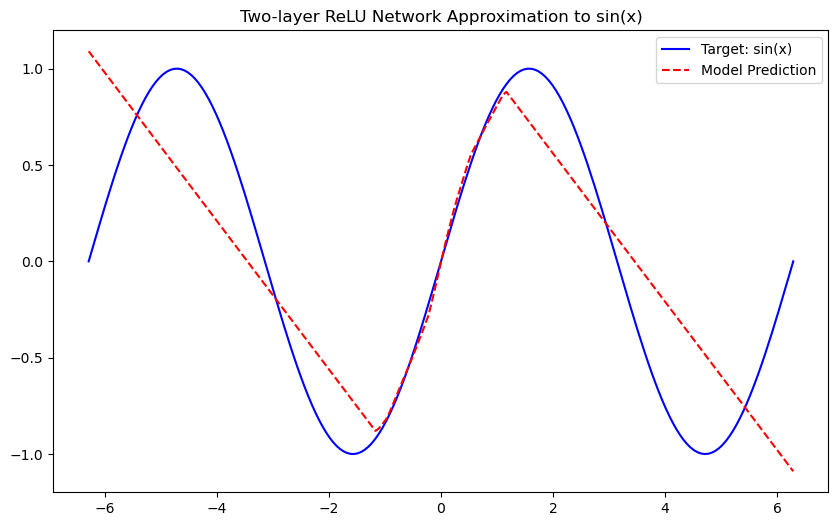

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定义两层ReLU神经网络
class ReLU_Net_Numpy:
    def __init__(self):
        # 网络参数存储在字典中
        self.params = {
            'W1': np.random.randn(1, 64) * np.sqrt(2. / 1),  # 输入到第一层，64个神经元
            'b1': np.zeros(64),
            'W2': np.random.randn(64, 1) * np.sqrt(2. / 64),  # 第二层到输出层
            'b2': np.zeros(1)
        }

    def relu(self, x):
        return np.maximum(0, x)

    def forward(self, x):
        self.h1 = self.relu(np.dot(x, self.params['W1']) + self.params['b1'])  # 第一层ReLU
        self.out = np.dot(self.h1, self.params['W2']) + self.params['b2']  # 第二层线性输出
        return self.out

class SGD:
    def __init__(self, params, lr=0.01, momentum=0.9, weight_decay=0.0):
        self.params = params
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.velocities = {key: np.zeros_like(value) for key, value in self.params.items()}

    def step(self, grads):
        for key in self.params:
            grad_with_decay = grads[key] + self.weight_decay * self.params[key]
            self.velocities[key] = self.momentum * self.velocities[key] - self.lr * grad_with_decay
            self.params[key] += self.velocities[key]


# 均方误差损失函数
def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

# 目标函数：正弦函数
def target_function(x):
    return np.sin(x)

# 生成训练数据
x_train = np.linspace(-2 * np.pi, 2 * np.pi, 100).reshape(-1, 1)  # 训练数据：x范围从-2π到2π
y_train = target_function(x_train)  # 目标输出：sin(x)
model = ReLU_Net_Numpy()
optimizer = SGD(model.params, lr=0.001, momentum=0.9, weight_decay=0.0001)

# 训练
num_epochs = 20000
for epoch in range(num_epochs):
    y_pred = model.forward(x_train)  # 前向传播
    loss = mse_loss(y_pred, y_train)  # 计算损失
    
    # 反向传播
    d_out = 2 * (y_pred - y_train) / y_train.size  # 损失关于输出的梯度
    d_W2 = np.dot(model.h1.T, d_out)  # 第二层权重的梯度
    d_b2 = np.sum(d_out, axis=0)  # 第二层偏置的梯度
    d_h1 = np.dot(d_out, model.params['W2'].T)  # 第一层激活的梯度
    d_h1[model.h1 <= 0] = 0  # ReLU的导数（对负值设置为0）
    d_W1 = np.dot(x_train.T, d_h1)  # 第一层权重的梯度
    d_b1 = np.sum(d_h1, axis=0)  # 第一层偏置的梯度
    
    # 更新参数
    grads = {'W1': d_W1, 'b1': d_b1, 'W2': d_W2, 'b2': d_b2}
    optimizer.step(grads)
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')

# 测试
x_test = np.linspace(-2 * np.pi, 2 * np.pi, 200).reshape(-1, 1)  # 测试数据
y_test = target_function(x_test)  # 目标输出
y_pred = model.forward(x_test)

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_test, label='Target: sin(x)', color='blue')
plt.plot(x_test, y_pred, label='Model Prediction', color='red', linestyle='--')
plt.legend()
plt.title('Two-layer ReLU Network Approximation to sin(x)')
plt.show()


#### 2. torch

Epoch 0, Loss: 0.6011112928390503
Epoch 100, Loss: 0.15532930195331573
Epoch 200, Loss: 0.13690185546875
Epoch 300, Loss: 0.1291564553976059
Epoch 400, Loss: 0.12203127890825272
Epoch 500, Loss: 0.1152869239449501
Epoch 600, Loss: 0.10893801599740982
Epoch 700, Loss: 0.10298331081867218
Epoch 800, Loss: 0.09733319282531738
Epoch 900, Loss: 0.09195518493652344
Epoch 1000, Loss: 0.08678961545228958
Epoch 1100, Loss: 0.0817713811993599
Epoch 1200, Loss: 0.07690650224685669
Epoch 1300, Loss: 0.0722338929772377
Epoch 1400, Loss: 0.0677657276391983
Epoch 1500, Loss: 0.0635254830121994
Epoch 1600, Loss: 0.05949656665325165
Epoch 1700, Loss: 0.055663157254457474
Epoch 1800, Loss: 0.0520167239010334
Epoch 1900, Loss: 0.04853794723749161
Epoch 2000, Loss: 0.04523678869009018
Epoch 2100, Loss: 0.042105142027139664
Epoch 2200, Loss: 0.039156146347522736
Epoch 2300, Loss: 0.03641761839389801
Epoch 2400, Loss: 0.03386428579688072
Epoch 2500, Loss: 0.0314679779112339
Epoch 2600, Loss: 0.0292379241436

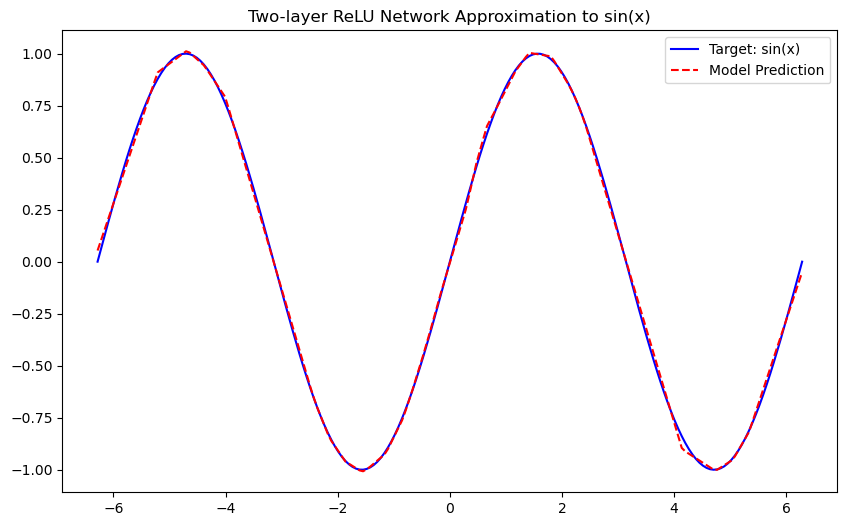

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 定义两层ReLU神经网络
class ReLU_Net(nn.Module):
    def __init__(self):
        super(ReLU_Net, self).__init__()
        self.fc1 = nn.Linear(1, 64)  # 第一层：从1维到64维
        self.fc2 = nn.Linear(64, 1)  # 第二层：从64维到1维

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 第一层ReLU
        x = self.fc2(x)  # 第二层线性输出
        return x

# 目标函数：正弦函数
def target_function(x):
    return torch.sin(x)

# 生成训练数据
x_train = torch.linspace(-2 * np.pi, 2 * np.pi, 100).view(-1, 1)  # 训练数据：x范围从-2π到2π
y_train = target_function(x_train)  # 目标输出：sin(x)
model = ReLU_Net()
criterion = nn.MSELoss()  # 使用均方误差损失函数
# optimizer = optim.SGD(model.parameters(), lr=0.002)
optimizer = optim.SGD(model.parameters(), lr=0.002, momentum=0.9)

# 训练模型
num_epochs = 20000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()  # 清除上一轮的梯度
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

# 测试模型
model.eval()
x_test = torch.linspace(-2 * np.pi, 2 * np.pi, 200).view(-1, 1)  # 测试数据
y_test = target_function(x_test)  # 目标输出
y_pred = model(x_test)

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(x_test.detach().numpy(), y_test.detach().numpy(), label='Target: sin(x)', color='blue')
plt.plot(x_test.detach().numpy(), y_pred.detach().numpy(), label='Model Prediction', color='red', linestyle='--')
plt.legend()
plt.title('Two-layer ReLU Network Approximation to sin(x)')
plt.show()
